**要求：**  
**1. 在优化器中加入动量Momentum 补充完整程序**  
**2. 使用Adam优化器，补充完整程序**  
**3. 对比分析两种优化器的结果差异**  

**思路：**  
**1. 按照相关要求补全代码即可**  
**2. 按照相关要求补全代码即可**

## MNIST数据集读取

In [1]:
import gzip
import os
import struct
import numpy as np
import matplotlib.pyplot as plt

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)
        images=images.astype(np.int32)

    idx=np.random.permutation(images.shape[0])
    images=images[idx]
    labels=labels[idx]

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)
    
    val_img = images[:offset][:]
    val_lb = labels[:offset]
    
    train_img = images[offset:][:]
    train_lb = labels[offset:]
    
    return train_img, train_lb, val_img, val_lb    

# 读取训练集和测试集数据
[images, labels] = load_mnist('./MNIST', kind='train')
[test_img, test_lb] = load_mnist('./MNIST',kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)


# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape)

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,)


## 用SGD+Momentum+CrossEntropyLoss来训练 Linear Classifier

### 定义Cross Entropy Loss

In [2]:
def vectorized_loss_softmax(X, y, W):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=50000 examples.
    
    Inputs:
    - W: Indexs of linear classifier, a numpy array of shape (D, C) containing weights.
    - X: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - y: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
         that X[i] has label c, where 0 <= c < C.
    
    Returns a tuple of:
    - Softmax loss as single float.
    """
    
    # set the value of delta, lamda
    delta = 1.0
    lamda = 1.0
    num_train = X.shape[0]
    num_class = W.shape[1]
    
    # scores: class x examples
    scores = W.T.dot(X.T).reshape(num_class, num_train)  #scores形状为(C,N)
    
    # scores_max: 1 x examples, get the max value from each column
    scores_max = np.reshape(np.max(scores, axis=0), (1, num_train))  #这里使用keepdims=True也可以

    # prob: class x examples, calculate the log probability
    # use scores_max to limit the boundary of exp indexes
    prob = np.exp(scores-scores_max) / np.sum(np.exp(scores-scores_max), axis=0)  #prob的形状为(C,N)
    prob = np.clip(prob, 1e-10, 1.0 - 1e-10)  # 把概率限制在[1e-10, 0.9999999999]，log永远有意义

    # set value 1 in true label positions, 0 for false labels
    y_true = np.zeros(prob.shape)
    y_true[y, np.arange(num_train)] = 1.0  #获得真实标签的独热编码
    
    # calculate the average data loss
    loss = -np.sum(y_true * np.log(prob))/num_train
    
    # add L1 regularization loss，添加了L1正则化
    rw = np.sum(np.abs(W))
    loss += lamda * rw
    
    return loss

### 定义梯度计算函数

In [3]:
# compute the numeric gradient
def compute_gradient(img, lb, X):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=1000 examples.
    
    Inputs:
    - img: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - lb: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
          that X[i] has label c, where 0 <= c < C.
    - X: Indexs of linear classifier, a numpy array of shape (D, C) containing weights.
    
    Returns:
    - Numeric gradient dx
    """
    
    # initalize the gradient matrix dx
    dx = np.zeros(X.shape)
    h = 0.0001
    
    # calculate the inital loss fx
    fx = vectorized_loss_softmax(img, lb, X)
    
    # iterate the each value
    for c in range(X.shape[1]):  #遍历类
        for d in range(X.shape[0]):  #遍历一种类下的一个特征
            # evaluate function(x+h)
            org_val = X[d][c]

            # increment by h
            X[d][c] = org_val + h

            # evalute the softmax loss for f(x+h)
            fxh = vectorized_loss_softmax(img, lb, X)

            # restore to previous value
            X[d][c] = org_val

            # compute the partial derivative
            dx[d][c] = (fxh - fx) / h

    return dx


### 定义SGD+Momentum优化器

In [4]:
# SGD training function
def Train_with_SGD(img, lb, epoches):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=1000 examples.
    
    Inputs:
    - img: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - lb: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
          that X[i] has label c, where 0 <= c < C.
    - epoch: Training iterations, an integer.
    
    Returns:
    - Best indexs X
    """
    
    # set the hyperparameters
    beta1 = 0.9
    beta2 = 0.999
    learning_rate = 5e-4
    first_momentum = 0
    second_momentum = 0

    #记录损失和准确率中间量，最后用于绘制变化图像
    losses=[]
    accuracies=[]
    
    # initialize the indexs X
    X = np.random.randn(img.shape[1], 10)*0.0001  #X的形状为(D,C)
    
    for i in range(1, epoch + 1):
        
        # compute the gradient
        dx = compute_gradient(img,lb,X)
        
        # momentum
        first_momentum = beta1 *first_momentum+ (1-beta1) *dx
        
        # update the indexs X
        X -= learning_rate *first_momentum 
        
        # calculate the loss and accuracy
        loss = vectorized_loss_softmax(img,lb,X)
        scores =  X.T.dot(img.T)  #scores的形状为(C,N)
        y_pred = np.argmax(scores, axis=0)
        accuracy = np.mean(y_pred == lb) * 100

        losses.append(loss)
        accuracies.append(accuracy)
        
        # print the result
        print("Epoch: %d  Loss: %.3f  Acc: %.3f%%" % (i, loss, accuracy))
    
    return X,losses,accuracies

### 在训练集上进行训练

Epoch: 1  Loss: 3.066  Acc: 43.700%
Epoch: 2  Loss: 7.017  Acc: 53.400%
Epoch: 3  Loss: 8.167  Acc: 64.100%
Epoch: 4  Loss: 9.116  Acc: 68.300%
Epoch: 5  Loss: 10.015  Acc: 64.900%
Epoch: 6  Loss: 10.179  Acc: 67.300%
Epoch: 7  Loss: 10.293  Acc: 71.600%
Epoch: 8  Loss: 10.510  Acc: 70.200%
Epoch: 9  Loss: 10.594  Acc: 71.200%
Epoch: 10  Loss: 10.586  Acc: 70.300%


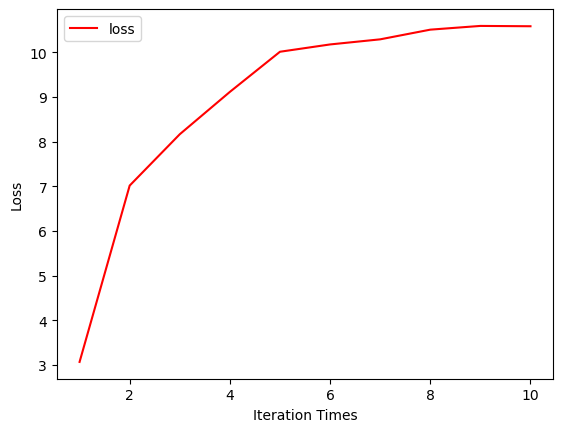

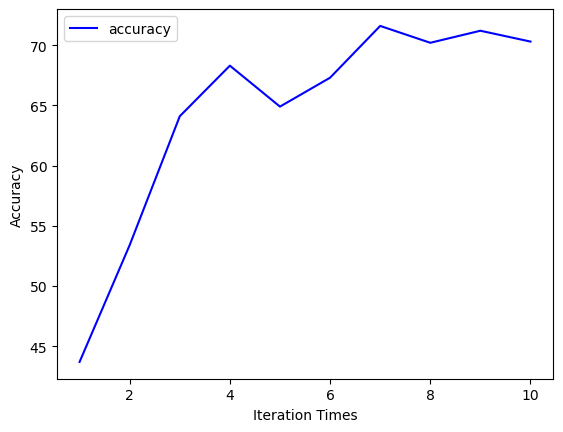

In [7]:
# train the linear classifier without adam in 1000 examples
epoch = 10

best_X,losses,accuracies= Train_with_SGD(train_img[:1000,:], train_lb[:1000], epoch)
plt.plot(np.arange(1,epoch+1),losses,color='red',label='loss')
plt.xlabel('Iteration Times')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(np.arange(1,epoch+1),accuracies,color='blue',label='accuracy')
plt.xlabel('Iteration Times')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 在验证集上测试分类效果

In [8]:
# test the classification accuracy on validation dataset

# scores: class x examples
scores =  best_X.T.dot(val_img.T)

# get the predicted labels
# y_pred: examples
y_pred = np.argmax(scores, axis=0)

# calculate the accuracy
accuracy = np.mean(y_pred == val_lb) * 100

# print the accuracy
print("SGD_Momentum优化器在验证集上的分类精度为: %.3f%%" % accuracy)

SGD_Momentum优化器在验证集上的分类精度为: 68.400%


## 使用Adam优化器进行训练

### 定义Adam

In [14]:

# Adam training function
def Train_with_Adam(img, lb, epoch):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=1000 examples.
    
    Inputs:
    - img: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - lb: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
          that X[i] has label c, where 0 <= c < C.
    - epoch: Training iterations, an integer.
    
    Returns:
    - Best indexs X
    """
    
    # set the hyperparameters
    beta1 = 0.9
    beta2 = 0.999
    learning_rate = 5e-4
    first_momentum = 0
    second_momentum = 0

    #记录损失和准确率中间量，用于绘制变化图像
    losses=[]
    accuracies=[]
    
    # initialize the indexs X
    X = np.random.randn(img.shape[1], 10) * 0.0001
    
    # start training
    for i in range(1, epoch + 1):
        # compute the gradient
        dx = compute_gradient(img, lb, X)
        
        # momentum
        first_momentum = beta1*first_momentum+(1-beta1)*dx
        # adagrad
        second_momentum = beta2*second_momentum+(1-beta2)*dx*dx
        
        # bias correction
        first_unbias = first_momentum/(1-beta1**i)
        second_unbias = second_momentum/(1-beta2**i)
        
        # update the indexs X
        X = X-learning_rate*first_unbias/(np.sqrt(second_unbias)+1e-7)
        
        # calculate the loss and accuracy
        loss = vectorized_loss_softmax(img, lb, X)
        scores =  X.T.dot(img.T)
        y_pred = np.argmax(scores, axis=0)
        accuracy = np.mean(y_pred == lb) * 100

        losses.append(loss)
        accuracies.append(accuracy)
        
        # print the result
        print("Epoch: %d  Loss: %.3f  Acc: %.3f%%" % (i, loss, accuracy))
    
    return X,losses,accuracies

### 在训练集上进行训练

Epoch: 1  Loss: 5.900  Acc: 49.300%
Epoch: 2  Loss: 6.497  Acc: 46.700%
Epoch: 3  Loss: 5.158  Acc: 61.800%
Epoch: 4  Loss: 5.200  Acc: 65.100%
Epoch: 5  Loss: 5.163  Acc: 70.400%
Epoch: 6  Loss: 4.894  Acc: 72.900%
Epoch: 7  Loss: 4.320  Acc: 75.600%
Epoch: 8  Loss: 4.107  Acc: 79.800%
Epoch: 9  Loss: 4.034  Acc: 80.900%
Epoch: 10  Loss: 3.844  Acc: 83.200%


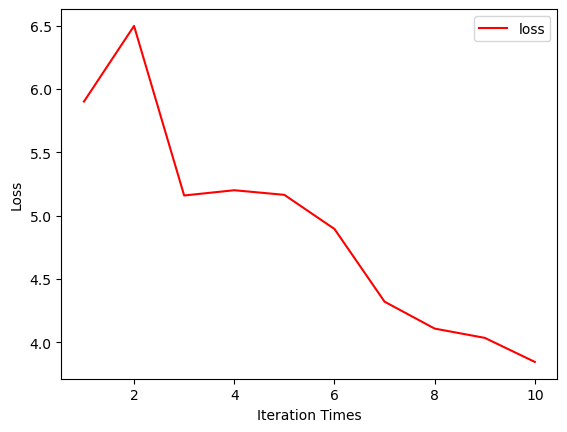

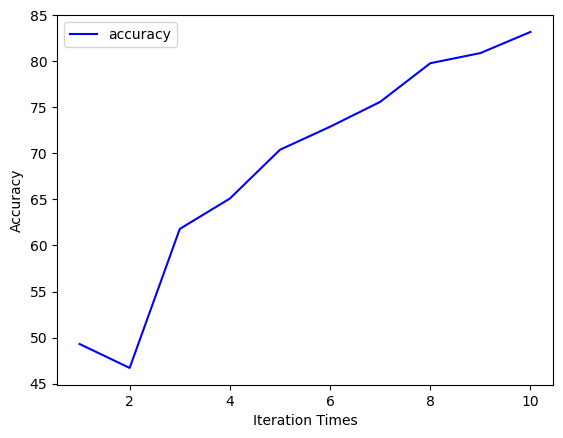

In [17]:
# train the linear classifier with adam in 1000 examples
epoch = 10
best_X,losses_with_Adam,accuracies_with_Adam= Train_with_Adam(train_img[0:1000,:], train_lb[0:1000], epoch)
plt.plot(np.arange(1,epoch+1),losses_with_Adam,color='red',label='loss')
plt.xlabel('Iteration Times')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(np.arange(1,epoch+1),accuracies_with_Adam,color='blue',label='accuracy')
plt.xlabel('Iteration Times')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 在验证集上测试分类效果

In [18]:
# test the classification accuracy on validation dataset

# scores: class x examples
scores =  best_X.T.dot(val_img.T)

# get the predicted labels
# y_pred: examples
y_pred = np.argmax(scores, axis=0)

# calculate the accuracy
accuracy = np.mean(y_pred == val_lb) * 100

# print the accuracy
print("SGD_Momentum优化器在验证集上的分类精度为: %.3f%%" % accuracy)

SGD_Momentum优化器在验证集上的分类精度为: 78.460%


**在此，我们将使用Momentum优化器和Adam优化器下的损失变化图像和准确率变化图像做对比**

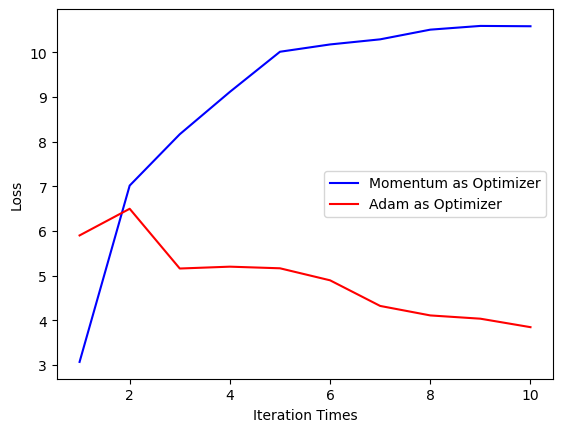

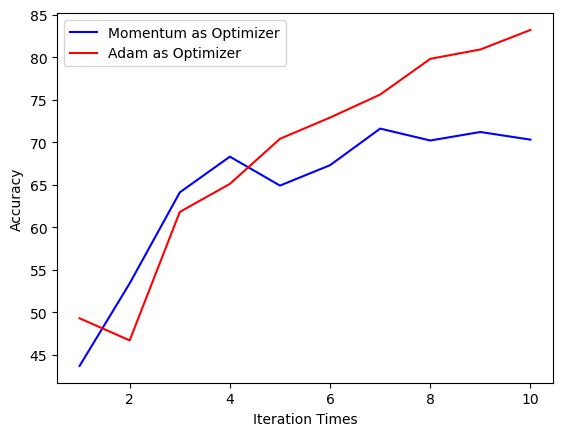

In [21]:
plt.plot(np.arange(1,epoch+1),losses,color='blue',label='Momentum as Optimizer')
plt.plot(np.arange(1,epoch+1),losses_with_Adam,color='red',label='Adam as Optimizer')
plt.xlabel('Iteration Times')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(np.arange(1,epoch+1),accuracies,color='blue',label='Momentum as Optimizer')
plt.plot(np.arange(1,epoch+1),accuracies_with_Adam,color='red',label='Adam as Optimizer')
plt.xlabel('Iteration Times')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 分析比较两种优化器的结果差异

首先因为算力资源有限，训练轮数设置的较少，且没有将所以样本投入训练过程中，每轮仅有1000张图片，因此即便使用了Adam作为优化器也存在一定的**震荡问题**，  
但是我们仍能明显看出**Adam比Momentum效果要更好**，我们可以从以下角度来分析这个结论：  

**1. 从损失角度来看，Momentum的损失整体呈现上升趋势，Adam的损失整体呈现下降趋势**  
这是因为Momentum优化器仅仅是解决了传统SGD算法中对于鞍点和局部最优解梯度为0的更新停滞问题，而并没有Adam中调整自适应学习率的特点，自始至终不变的学习率导致更新过程中频繁发生**梯度震荡**，最终促成损失快速上升，不过这并不是**梯度爆炸**，因为损失在显著上升但是准确率整体也在上升，就是说此时模型正在学习每个样本和其标签之间的匹配联系，但是**置信度**却变差了（和之前第二次实验报告里写的类似，**损失最小化和准确率最大化追求的目标本质上是不同的**）  
相比之下，Adam通过调整自适应学习率，让模型更新到梯度大的地方时步长小一些，更新到梯度小的地方时步长大一些，这就明显缓解了梯度震荡的问题  

**2. 从准确率的角度来看，Momentum存在欠拟合，震荡严重，Adam表现较为良好**  
经过10轮更新后，使用Momentum作为优化器的模型准确率停滞在70%左右，存在明显的**欠拟合问题**，原因就是其在一个最优解附近不断徘徊震荡（Momentum就是物理学中“动量”的意思，此时就好像是在一个光滑的碗的碗沿上放置一个小球，显然小球会做类简谐运动，不能在最低点处停下来），无法接近最优解对应点，同时更新过程中也存在严重震荡问题  
而使用Adam作为优化器时则几乎不存在震荡问题，这也是自适应学习率的功劳，虽然10轮更新之后模型准确率在85%左右，但是从图像中我们可以明显看出图像仍有很大的上升空间，可以认为此时不存在严重的欠拟合问题
并且对于验证集，也能直接看出Adam的表现由于Momentum，即便是因为训练数据和训练次数过少，两者都存在**过拟合问题**

In [ ]:
##完结撒花##
#  /\_____/\
# (  ◕‿◕  )
#  >     <  )
# (       )
#  U-----U     哈基米哈基米哈基米胖宝宝胖宝宝胖宝宝
#              AUV小白手套好胖好可爱